# TD 7 : Tests non paramétriques pour comparer deux échantillons indépendants ou appariés

Matthias Grenié, Christelle Gonindard, Margaux Leroy, Vaéa Tesan et François Bettega



<div class="alert alert-info" role="alert">

## Objectifs

* Comprendre le principe des tests non paramétriques
* Savoir mobiliser les tests non paramétriques quand on ne valide pas les conditions d'applications des tests paramétriques
* Connaître les hypothèses du test de Mann-Whitney de comparaison de moyennes de deux échantillons indépendants
* Mettre en place le test de Mann-Whitney avec `wilcox.test(...)`
* Mettre en place le test de Mann-Whitney de comparaison avec une moyenne théorique *X* : `wilcox.test(..., mu = X)`
* Connaître les hypothèses du test de Wilcoxon de comparaison de moyennes de deux échantillons appariés
* Mettre en place le test de Wilcoxon avec `wilcox.test(..., paired = TRUE)`

</div>

---

## 1. Contexte : Pourquoi faire des tests non paramétriques

Ces tests ne nécessitent pas d’hypothèses contraignantes sur les distributions. Ils ne nécessitent pas de conditions d’application ou suppositions quelconques, par exemple :

- Il n'est pas nécessaire de faire des hypothèses sur la forme des distributions (par exemple, une distribution normale),
- il n'est pas nécessaire non plus d’estimer les paramètres associés (par exemple, estimer la moyenne à partir de l'échantillon).

Leur champ d’application est par conséquent plus large que les tests paramétriques.

**Les tests non paramétriques sont également adaptés aux données ordinales** (c'est-à-dire les données avec des catégories ordonnées). Bien souvent, les données disponibles sont des ordres de grandeur ou des données ordonnées par classe, il est difficile de donner une interprétation à la valeur précise. Dans ce cas, le plus important est la position relative des observations, leur ordonnancement, plutôt que leurs valeurs exactes.

*Exemples :*
1. Lorsque les données s’expriment comme des degrés de préférence (par exemple, [l'échelle de Likert](https://fr.wikipedia.org/wiki/%C3%89chelle_de_Likert) : tout à fait d'accord (valeur : **2**), d'accord (**1**), ni en désaccord ni d'accord (**0**), pas d'accord (**-1**), pas du tout d'accord (**-2**)), avec peu de valeurs possibles,
2. lorsque les données sont catégorielles.

**Robustesse par rapport aux points aberrants**: la transformation des données en rangs rend les statistiques non paramétriques bien moins sensibles aux points aberrants que les statistiques paramétriques.

*En effet, la présence d’un point atypique (**outlier** en anglais) fausse très souvent la moyenne, qui joue un rôle central dans les tests paramétriques. Si le point atypique correspond à une très grande valeur, s’écartant fortement des autres, la moyenne est "tirée" vers le haut, biaisant tous les calculs subséquents. Avec les rangs, seule l’information "le point correspond à la valeur la plus élevée / la moins élevée", est considérée, sans ordre de grandeur, le rôle problématique de l’observation atypique est donc amoindri.*

## 2. Test de comparaison non paramétrique de deux échantillons indépendants : Test de Mann-Whitney

Il est important de prendre conscience qu’en statistiques, le choix du test est primordial et répond
à des conditions.  Nous allons donc vous présenter dans cette fiche, différents tests possibles
pour comparer les valeurs numériques (variable quantitative) de deux échantillons indépendants
 :
1. si les effectifs des deux groupes sont ≥ 30 : on applique le test de Student paramétrique vu au semestre précédent
2. si l’effectif d’un des groupes, voir les deux sont < 30, deux possibilités :
    - si les données suivent une loi normale et si les variances entre les groupes sont égales : test de Student ;
    - si l’une des conditions citées ci-dessus n’est pas vérifiée : test de Mann-Whitney (non paramétrique).


### 2.1 Principe du test 

Le test de Mann-Whitney utilise les **RANGS** des données (premier, deuxième, etc.) et non les données elles-mêmes,
c’est-à-dire l’ordre dans lequel apparaissent les observations des deux échantillons réunis :

1. Le test attribue un rang aux valeurs des deux échantillons considérés ensemble (premier, deuxième, troisième, etc.).
2. À partir de cela, la moyenne des rangs pour chaque échantillon est calculée. Le principe étant que s'il n’y a pas de différence entre les deux échantillons (H0) alors les rangs moyens devraient être égaux (Statistique U de Mann-Whitney)

<img src="figures/Mann_Whitney.png" />

### 2.2 Exemple : Comparaison de 2 régimes alimentaires

Deux groupes de 10 lapins avec un régime enrichi en cholestérol ont été soumis à 2 traitements différents, **x** et **y**, pour lutter contre le cholestérol.  
Les résultats sont-ils différents entre les deux régimes au seuil 2% ?

La cholestérolémie est observée en dg⋅L$^{-1}$. 

Les données sont contenues dans le fichier texte *`data_lapin.txt`* qui se trouve dans le dossier `data` (chemin d'accès relatif par rapport à la fiche de TD : `data/data_lapin.txt`.

#### 1. Lire les données


In [1]:
lapin = read.table("data/data_lapin.txt", header = TRUE)
head(lapin)

,x,y
,<int>,<int>
1,23,18
2,15,22
3,28,33
4,26,334
5,13,19
6,28,32


#### 2. Décrire et présenter les données

       x              y         
 Min.   :13.0   Min.   : 18.00  
 1st Qu.:21.5   1st Qu.: 23.25  
 Median :24.5   Median : 31.50  
 Mean   :23.2   Mean   : 58.10  
 3rd Qu.:27.5   3rd Qu.: 32.75  
 Max.   :29.0   Max.   :334.00  

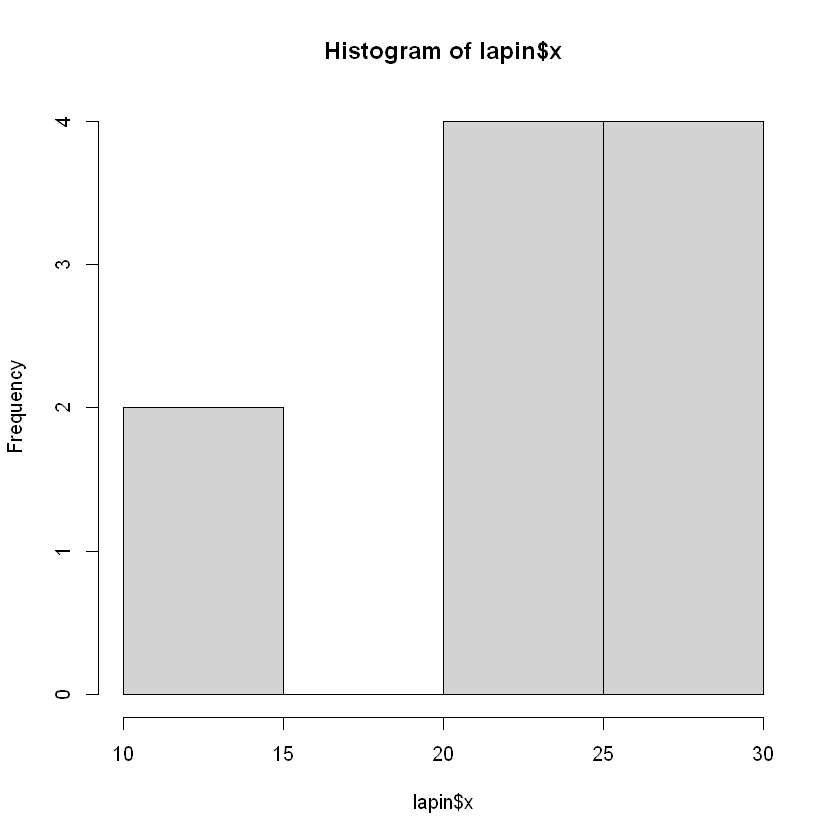

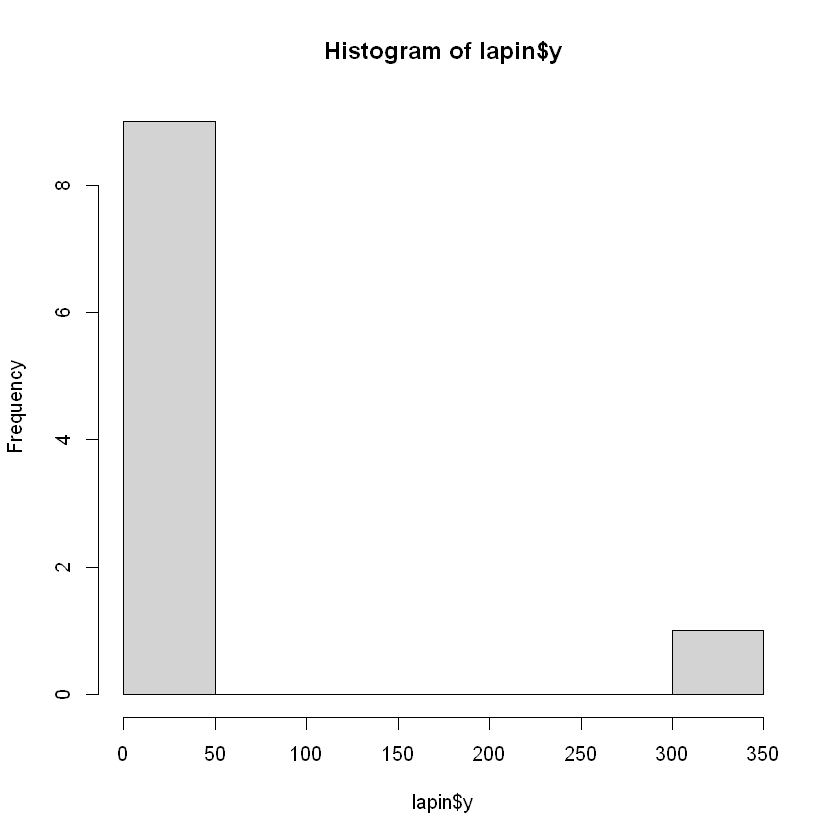

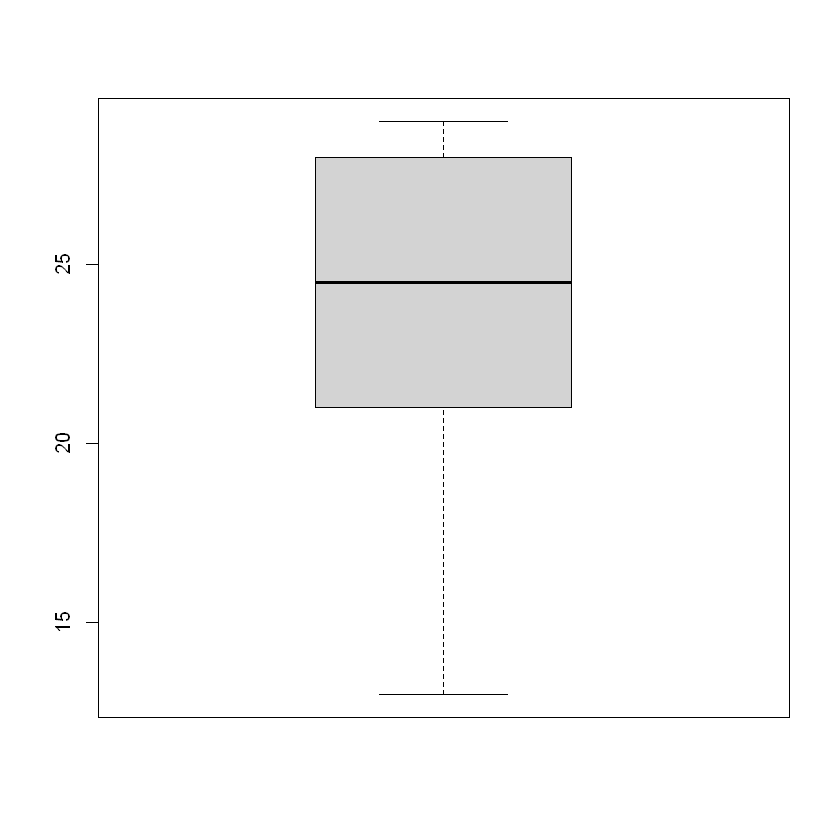

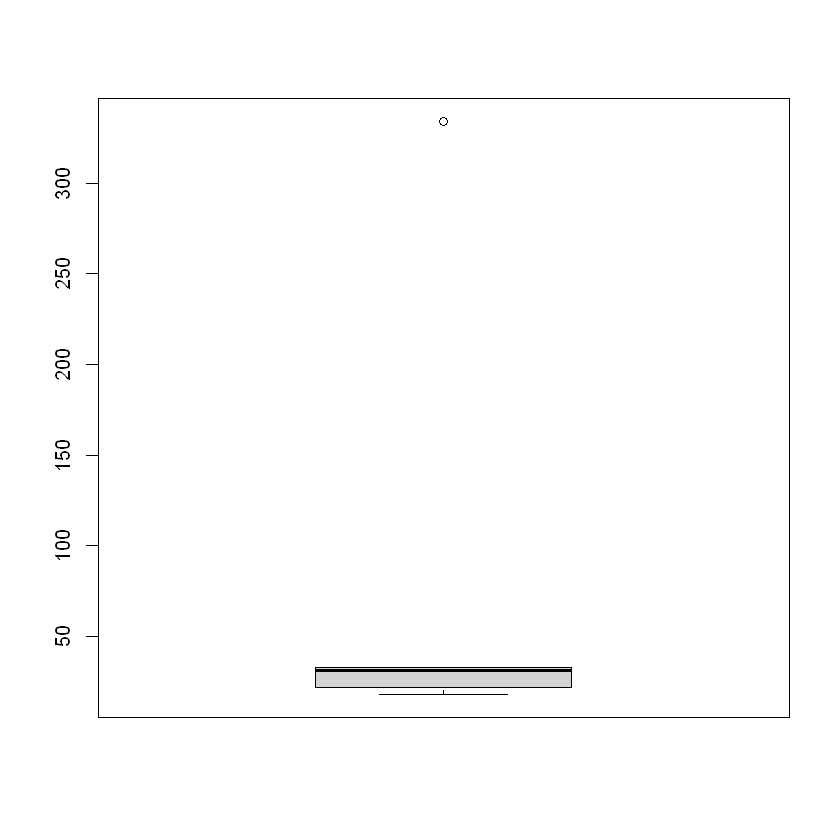

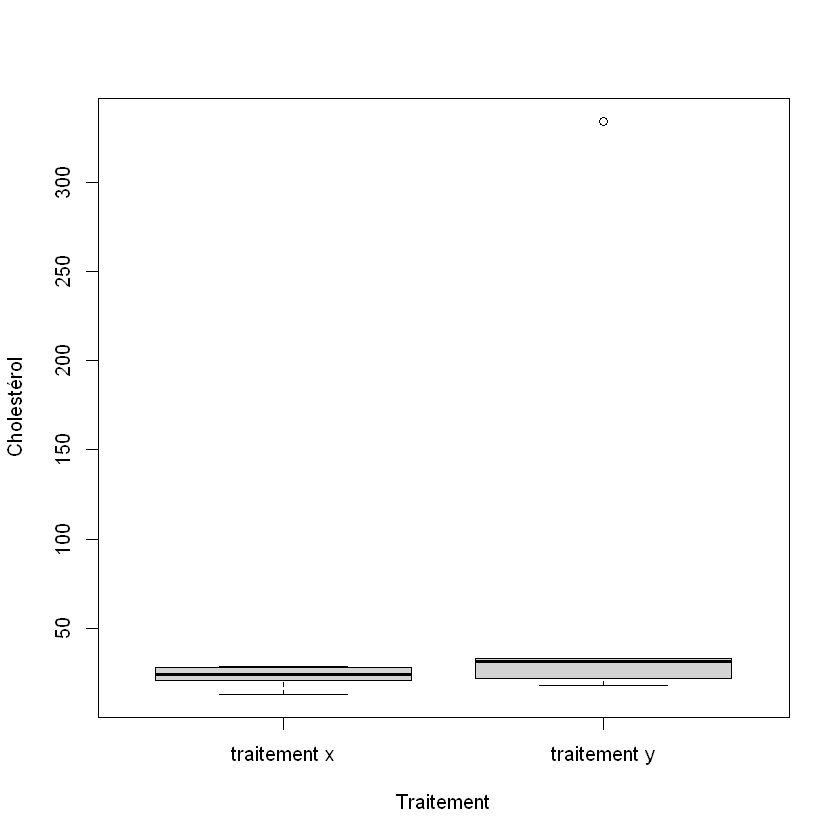

In [2]:
summary(lapin)
hist(lapin$x)
hist(lapin$y)
boxplot(lapin$x)
boxplot(lapin$y)

boxplot(lapin$x, lapin$y, xlab = "Traitement", ylab = "Cholestérol", names = c("traitement x", "traitement y"))

**Commentez** :
Les données contiennent deux colonnes, une pour chaque traitement anti-cholestérol. On observe que les lapins traités avec le traitement **y** ont un taux de cholestérol plus élevé que les lapins traités avec **x**. En outre, pour le traitement **y** on observe que le lapin avec le plus fort taux de cholestérol a un taux de 334 $dg⋅L^{-1}$, ce qui est plus de 10 fois supérieur au niveau plus élevé que le maximum observé pour le traitement **x**.



#### 3. Pourrait-on faire un test de Student pour comparer les traitements ?  


In [3]:
# Vérification des conditions d'application du test de Student
length(lapin$x)

# n < 30, il faut vérifier la normalité des distributions
shapiro.test(lapin$x)
shapiro.test(lapin$y)

[1] 10


	Shapiro-Wilk normality test

data:  lapin$x
W = 0.88222, p-value = 0.1384



	Shapiro-Wilk normality test

data:  lapin$y
W = 0.42042, p-value = 4.298e-07


**Concluez** :  
Au seuil $\alpha = 5\%$, on observe p > $\alpha$ pour le traitement **x**, donc la cholestérolémie pour le traitement **x** suit une distribution normale.  
En revanche, pour le traitement **y**, on obsever p < $\alpha$, donc la cholestérolémie pour ce traitement ne suit pas une distribution normale.  
On ne peut donc pas effectuer un test de Student pour comparer les moyennes de cholestérolémie entre les traitements.


#### 4. Hypothèses du test de Mann-Whitney

On souhaite vérifier si les régimes alimentaires ont des effets différents, on va donc faire un test bilatéral :

<div class="alert alert-warning" role="alert">

**Hypothèses**

H0 : La moyenne des cholestérolémies est **identique** entre les traitements **x** et **y**

H1 : La moyenne des cholestérolémies est **différente** entre les traitements **x** et **y**

</div>

#### 5. Réalisation du test 


**Remarque : pour le test de Mann-Whitney, il faut bien utiliser la fonction `wilcox.test()`,
elle permet à la fois de réaliser le test de Mann-Whitney mais également celui de Wilcoxon
comme on le verra par la suite**.  
Cette fonction s'utilise en utilisant les deux échantillons successivement comme arguments de la fonction

*Note : vous allez obtenir un message rouge qui indique qu'on ne peut pas calculer de p-value exacte avec des ex-aequos, c'est le cas car il y a plusieurs lapins ayant exactement la même cholestérolémie. Vous pouvez quand même effectuer le test et l'interpréter*

In [4]:
# Réalisation du test
wilcox.test(lapin$x, lapin$y)

Warning message in wilcox.test.default(lapin$x, lapin$y):
"impossible de calculer la p-value exacte avec des ex-aequos"



	Wilcoxon rank sum test with continuity correction

data:  lapin$x and lapin$y
W = 26, p-value = 0.07533
alternative hypothesis: true location shift is not equal to 0


**En conclusion :**  
Au seuil $\alpha = 5\%$, on observe que $p = 0.075 > \alpha$, donc on accepte H0, ce qui signifie que les deux distributions sont identiques.

### 2.3 Comparaison de la médiane à 25 dg·L⁻¹

Question supplémentaire : vérifier si la médiane (pour chacun des deux échantillons) est égale à la valeur 25 dg⋅L$^{-1}$ attendue par l’expérimentatrice ?

Dans le cas présent, il va falloir faire deux tests :

1. Comparaison de la **médiane** de l’échantillon **x** à la valeur théorique 25.
2. Comparaison de la **médiane** de l’échantillon **y** à la valeur théorique 25.

D’après la description des données précédentes, nous avons pu observer que la médiane du groupe x est égale à 24.5 et celle du groupe y est égale à 31.5. Celle du groupe x semble plus proche de $\mu_0=25$ que la médiane du groupe y. Toutefois, ces valeurs ont été obtenues à partir de petits échantillons, nous allons donc vérifier si l’écart qui est observé est peu probable ou simplement dû au hasard.
Les hypothèses des deux tests sont les suivantes :

H0 : La médiane est égale à 25  
H1 : La médiane est différente de 25

Pour mettre en place le test de comparaison d'une médiane à une valeur théorique, on utilise les mêmes arguments que pour comparer une moyenne à une valeur théorique avec le test de Student et la fonction `t.test()`, mais en utilisant la fonction `wilcox.test()`. À savoir qu'on précise comme premier argument l'échantillon et comme argument `mu=`, la médiane théorique.

In [5]:
# comparer la médiane de l’échantillon x à la valeur théorique 25
wilcox.test(lapin$x, mu = 25)

# comparer la médiane de l’échantillon y à la valeur théorique 25
wilcox.test(lapin$y, mu = 25)

Warning message in wilcox.test.default(lapin$x, mu = 25):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(lapin$x, mu = 25):
"impossible de calculer une p-value exacte avec des zéros"



	Wilcoxon signed rank test with continuity correction

data:  lapin$x
V = 17, p-value = 0.5526
alternative hypothesis: true location is not equal to 25


Warning message in wilcox.test.default(lapin$y, mu = 25):
"impossible de calculer la p-value exacte avec des ex-aequos"



	Wilcoxon signed rank test with continuity correction

data:  lapin$y
V = 43.5, p-value = 0.1127
alternative hypothesis: true location is not equal to 25


**Conclusion :**  
Au seuil $\alpha = 5\%$, on observe que p > $\alpha$ pour les deux traitements, on accepte donc H0 pour les deux, cela signifie que la médiane des deux traitements est égale à 25.

## 3. Comparaison non paramétrique de deux échantillons appariés : test de Wilcoxon

Comme pour la comparaison de deux échantillons indépendants, le choix du test lors de la comparaison de deux échantillons appariés va dépendre des conditions d’application :
1. Si l’effectif de l’échantillon est ≥ 30 : on applique le test de Student paramétrique pour données appariées,
2. si l’effectif de l’échantillon est < 30, deux possibilités :
    - si les données suivent une loi normale : test de Student pour données appariées
    - si la normalité n’est pas vérifiée : test de Wilcoxon (non paramétrique)


### 3.1 Principe du test 

Comme le test de Mann-Whitney, le test de Wilcoxon travaille sur des rangs. Les échantillons (nommés ci-après
**A** et **B**) étant appariés, le test procède schématiquement ainsi :
1. Il calcule pour chaque individu la différence entre sa valeur dans l’échantillon A et sa valeur dans l’échantillon B,
2. pour chaque différence calculée, il assigne un rang en valeur absolue de manière croissante (la différence la plus petite a le rang 1, etc.),
3. il calcule la somme des rangs qui ont une différence positive ($R^+$) et la somme des rangs qui ont une valeur négative ($R^-$),
4. puis il teste si le nombre des écarts positifs est différent du nombre des écarts négatifs (respectivement, plus élevée ou plus rare dans le cas des tests unilatéraux),
5. si on observe une différence, ça signifie que les échantillons sont différents (si les échantillons étaient proches $R^+$ et $R^-$ devraient être peu différents).

<img src="figures/Wilcox.png" />


### 3.2 Exemple : Comparaison de l’effet de deux somnifères

On veut tester les effets de deux drogues sur le sommeil, l’hiocyamine et l’hyoscine. L’une
des deux drogues est-elle un somnifère plus puissant au seuil 5% ?

Les drogues ont été administrées à 10 patients. On mesure alors le temps pendant lequel chaque patient a dormi sans drogue et après l’administration de 0,6 mg de l’une puis de l’autre drogue. Un délai d’une semaine est
laissé entre chaque mesure afin d’éliminer complètement l’effet des drogues. Les valeurs données
dans le tableau ci-dessous correspondent au temps supplémentaire dormi en présence de la
drogue par rapport au temps de sommeil habituel.

**Comparer les effets des deux drogues sur le sommeil.**

Les données sont contenues dans le fichier texte `data_somnifere.txt` qui se trouve dans le dossier `data` (chemin d'accès relatif complet `data/data_somnifere.txt`).

#### Lecture et description des données

1. Lecture des données

In [6]:
dodo = read.table("data/data_somnifere.txt", header = TRUE)
head(dodo)

,patient,hiocyamine,hyoscine
,<int>,<dbl>,<dbl>
1,1,0.7,1.9
2,2,-1.6,0.8
3,3,-0.2,1.1
4,4,-1.2,0.1
5,5,-0.1,-0.1
6,6,3.4,4.4


2. Description des données :

    patient        hiocyamine        hyoscine     
 Min.   : 1.00   Min.   :-1.600   Min.   :-0.100  
 1st Qu.: 3.25   1st Qu.:-0.175   1st Qu.: 0.875  
 Median : 5.50   Median : 0.350   Median : 1.750  
 Mean   : 5.50   Mean   : 0.750   Mean   : 2.330  
 3rd Qu.: 7.75   3rd Qu.: 1.700   3rd Qu.: 4.150  
 Max.   :10.00   Max.   : 3.700   Max.   : 5.500  

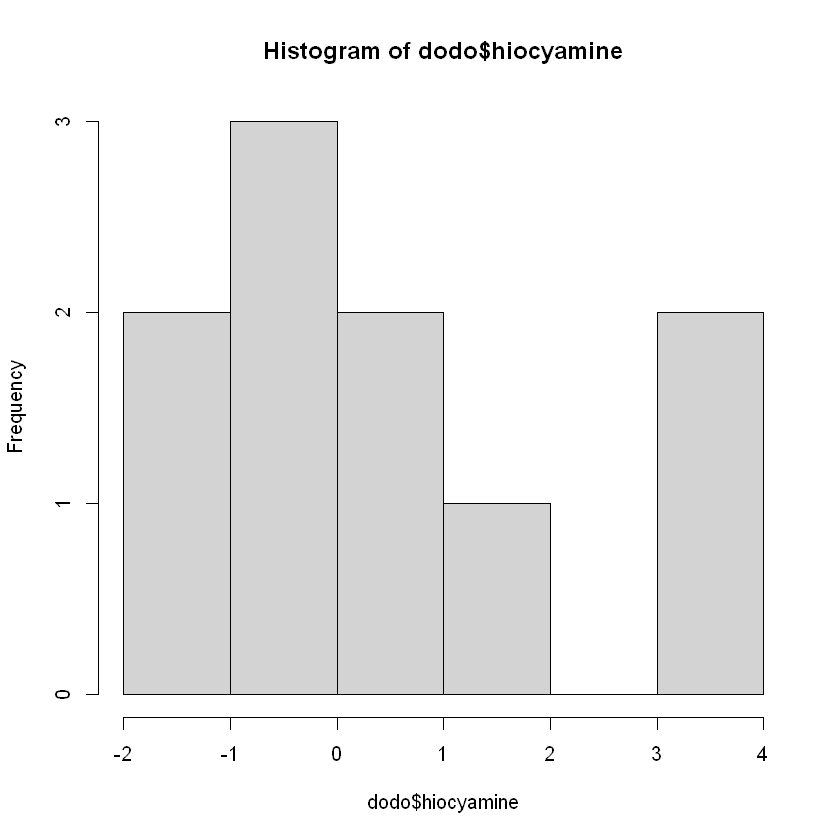

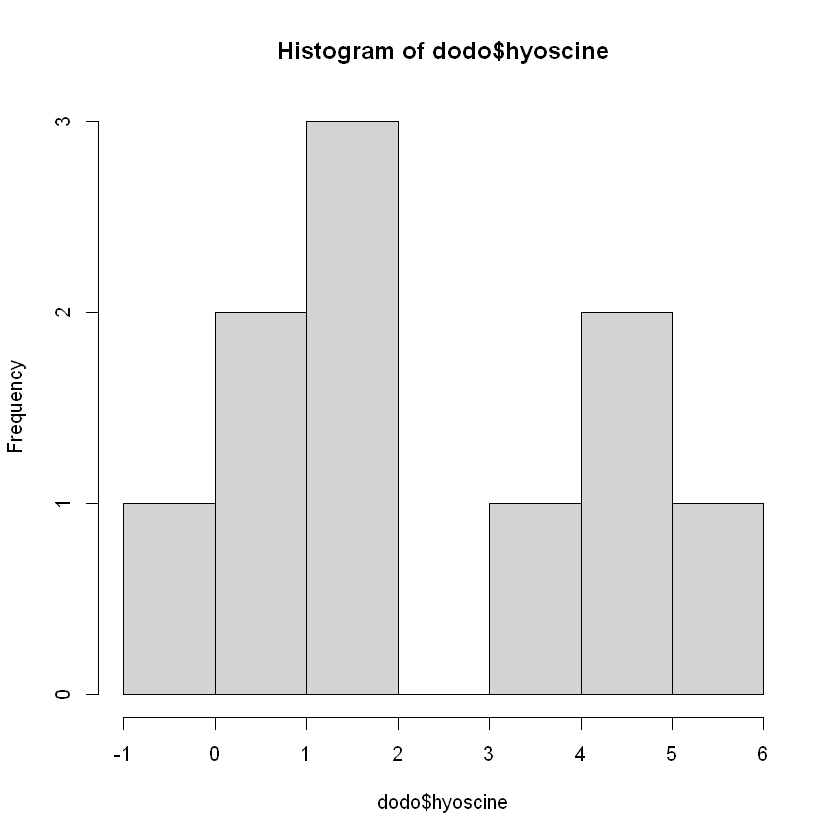

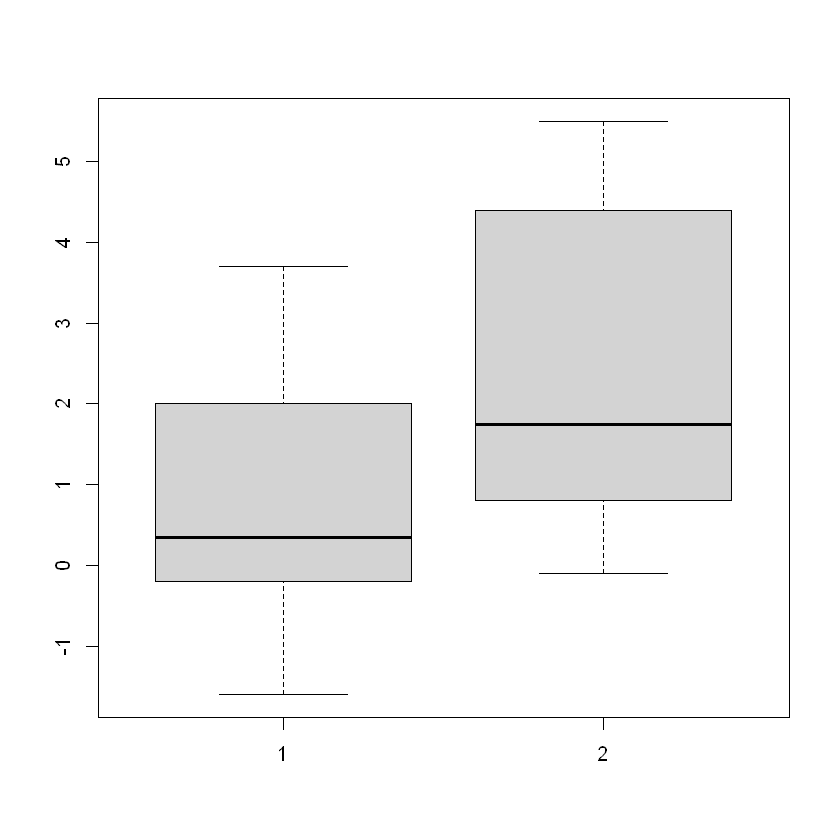

In [8]:
# Nos données sont appariées, il est plus informatif de représenter la différence, notée 'd'
summary(dodo)

hist(dodo$hiocyamine)
hist(dodo$hyoscine)

boxplot(dodo$hiocyamine, dodo$hyoscine)

In [9]:
dodo$d = dodo$hyoscine - dodo$hiocyamine

head(dodo)

,patient,hiocyamine,hyoscine,d
,<int>,<dbl>,<dbl>,<dbl>
1,1,0.7,1.9,1.2
2,2,-1.6,0.8,2.4
3,3,-0.2,1.1,1.3
4,4,-1.2,0.1,1.3
5,5,-0.1,-0.1,0.0
6,6,3.4,4.4,1.0


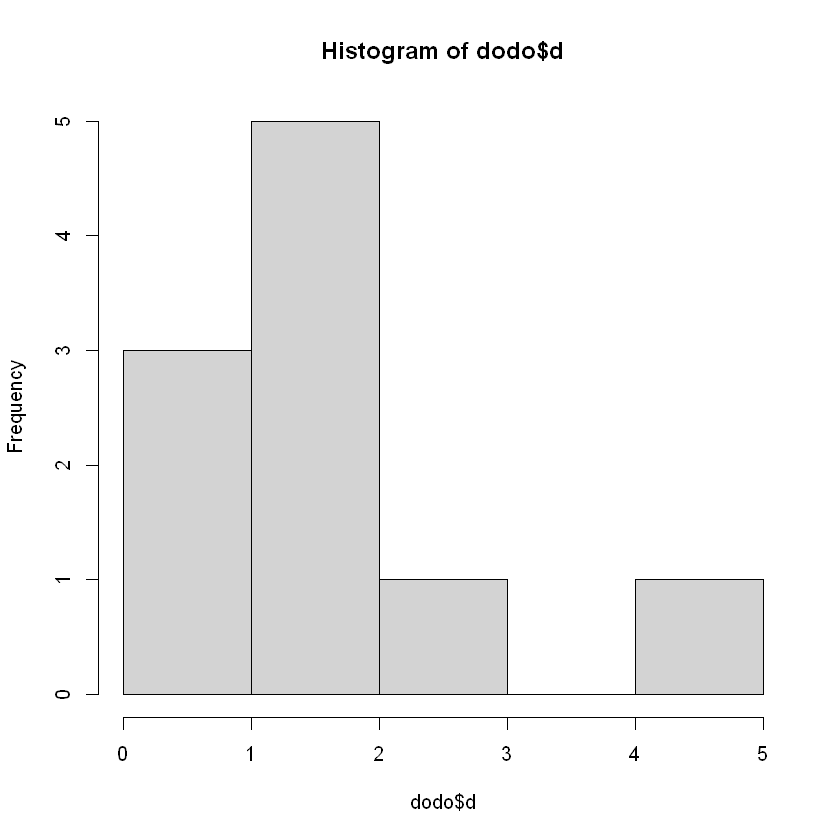

In [10]:
hist(dodo$d)

**Commentez**  
On observe que l'hyoscine semble avoir un effet plus important sur le sommeil que l'hiocyamine car la distribution de la première est plus positive que la seconde.  
En outre, on observe que la distribution de la différence (hyioscine - hiocyamine) est positive ce qui va dans le même sens.

3. Vérification de la normalité de $d$ (= est-il possible d'effectuer un test de Student pour données appariées ?)

In [13]:
shapiro.test(dodo$d)


	Shapiro-Wilk normality test

data:  dodo$d
W = 0.82987, p-value = 0.03334


**Concluez**  
Au seuil $\alpha = 5\%$, on observe que $p = 0.03 < \alpha$, ce qui signifie que $d$ ne suit pas une loi Normale.

#### Hypothèses et réalisation du test de Wilcoxon

4. Hypothèses du test

On souhaite vérifier si l’hyoscine soit plus efficace que l’hiocyamine, on va donc faire un
test **unilatéral**.

<div class="alert alert-warning" role="alert">

**Hypothèses** :

H0 : l'hyoscine et l'hiocyamine ont la même moyene (la moyenne des différences $d$ vaut 0)

H1 : l'hyoscine a une moyenne supérieure à l'hiocyamine (la moyenne des différences $d$ est supérieure à 0)

</div>

5. Réalisation du test

Pour effectuer le test de Wilcoxon, on procède comme pour un test de Student de comparaison de moyenne d'échantillons appariés. Dans la fonction `wilcox.test()` il faut préciser les arguments suivants :
1. le premier échantillon,
2. le deuxième échantillon,
3. comme pour le test de Student, on ajoute l'argument **`paired = TRUE`** pour préciser que nos échantillons sont **appariés**,
4. comme on cherche à effectuer un test **unilatéral** (voir les hypothèses ci-dessus), on préciser l'argument **`alternative=`** (qui prend les valeurs **`"greater"`** ou **`"less"`**, en fonction de l'ordre des échantillons et de l'hypothèse que l'on veut tester).

Réaliser le test complet ci-dessous :

In [14]:
# En utilisant les deux échantillons
wilcox.test(dodo$hyoscine, dodo$hiocyamine, paired = TRUE, alternative = "greater")

# En utilisant la distribution des différences 'd'
wilcox.test(dodo$d, alternative = "greater")

Warning message in wilcox.test.default(dodo$hyoscine, dodo$hiocyamine, paired = TRUE, :
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(dodo$hyoscine, dodo$hiocyamine, paired = TRUE, :
"impossible de calculer une p-value exacte avec des zéros"



	Wilcoxon signed rank test with continuity correction

data:  dodo$hyoscine and dodo$hiocyamine
V = 45, p-value = 0.004545
alternative hypothesis: true location shift is greater than 0


Warning message in wilcox.test.default(dodo$d, alternative = "greater"):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(dodo$d, alternative = "greater"):
"impossible de calculer une p-value exacte avec des zéros"



	Wilcoxon signed rank test with continuity correction

data:  dodo$d
V = 45, p-value = 0.004545
alternative hypothesis: true location is greater than 0


**En conclusion** :  
Au seuil $\alpha$ = 5%, on observe que p < $\alpha$, donc on rejette H0, ce qui signifie que l'hyoscine est plus efficace que l'hiocyamine.

<div class="alert alert-success" role="alert">
    
## Résumé

* On a pu rappeler les conditions d'application du test de Student de comparaison de deux échantillons indépendants
* On peut appliquer le test de Mann-Whitney de comparaison non paramétrique de moyenne de deux échantillons indépendants avec `wilcox.test(...)`
* On peut appliquer le test de Mann-Whitney de comparaison non paramétrique d'un échantillon à une moyenne théorique *X* avec `wilcox.test(..., mu = X)`
* On a pu rappeler les conditions d'application du  test de Student de comparaison de deux échantillons appariés
* On peut appliquer le test de Wilcoxon de comparaison non paramétrique de moyenne de deux échantillons appariés avec `wilcox.test(..., paired = TRUE)`
</div>

## 4. Exercices d'applications

## Exercice 1 

Pour déterminer l’indice d’iode de deux huiles **H1** et **H2**, on a réalisé respectivement neuf et dix
dosages. Les indices d’iode sont contenus dans le fichier *`data_exercice1.txt`* qui se trouve dans le dossier `data`.

Question : l’indice d’iode diffère-t-il pour les 2 huiles au seuil $\alpha=5\%$ ?

In [15]:
huiles = read.table("data/data_exercice1.txt", header = TRUE)

# Description des données
head(huiles)
summary(huiles)

# Vérification condition d'application
nrow(huiles)
shapiro.test(huiles$H1)
shapiro.test(huiles$H2)

# -> On ne peut pas faire de test de Student car H2 ne suit pas une loi normale
# -> Si on veut comparer l'indice d'iode entre les huiles, il faut effectuer un test de Mann-Whitney

# Hypothèses
# H0 : Le taux d'iode est le même entre les deux huiles
# H1 : le taux d'iode est différent entre les deux huiles

wilcox.test(huiles$H1, huiles$H2)

# Au seuil alpha = 5%, on observe que p < alpha, donc on rejette H0, ce qui signifie que les huiles ont un taux d'iode différent

,H1,H2
,<dbl>,<dbl>
1,65.5,88.7
2,65.3,66.7
3,67.1,69.3
4,66.4,67.8
5,67.1,73.7
6,68.4,76.4


       H1              H2       
 Min.   :65.30   Min.   :66.70  
 1st Qu.:66.40   1st Qu.:69.35  
 Median :67.10   Median :72.05  
 Mean   :67.48   Mean   :73.04  
 3rd Qu.:68.40   3rd Qu.:74.08  
 Max.   :71.50   Max.   :88.70  
 NA's   :1                      

[1] 10


	Shapiro-Wilk normality test

data:  huiles$H1
W = 0.91046, p-value = 0.3191



	Shapiro-Wilk normality test

data:  huiles$H2
W = 0.81737, p-value = 0.02355


Warning message in wilcox.test.default(huiles$H1, huiles$H2):
"impossible de calculer la p-value exacte avec des ex-aequos"



	Wilcoxon rank sum test with continuity correction

data:  huiles$H1 and huiles$H2
W = 11, p-value = 0.00621
alternative hypothesis: true location shift is not equal to 0


## Exercice 2

Chez quinze sujets, on mesure la fréquence cardiaque (FC) avant et après les avoir soumis à
une épreuve de deux minutes consistant à leur faire entendre des bruits d’intensité supérieure à
80 décibels. 


Les résultats de cette expérience, contenus dans le fichier *`data_exercice2.txt`*, qui se trouve dans le dossier `data`, permettent-ils de conclure au risque d'erreur $\alpha$=5% et au risque $\alpha$=1%, à un effet de l’épreuve sonore sur la fréquence cardiaque ?

,sujet,avant,apres
,<int>,<int>,<int>
1,1,90,95
2,2,73,77
3,3,82,90
4,4,92,95
5,5,87,81
6,6,68,90


     sujet          avant           apres      
 Min.   : 1.0   Min.   :61.00   Min.   :62.00  
 1st Qu.: 4.5   1st Qu.:65.50   1st Qu.:72.50  
 Median : 8.0   Median :70.00   Median :77.00  
 Mean   : 8.0   Mean   :72.67   Mean   :78.67  
 3rd Qu.:11.5   3rd Qu.:77.50   3rd Qu.:85.50  
 Max.   :15.0   Max.   :92.00   Max.   :95.00  

,sujet,avant,apres,difference
,<int>,<int>,<int>,<int>
1,1,90,95,-5
2,2,73,77,-4
3,3,82,90,-8
4,4,92,95,-3
5,5,87,81,6
6,6,68,90,-22


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  -22.0    -8.0    -6.0    -6.0    -4.5     6.0 

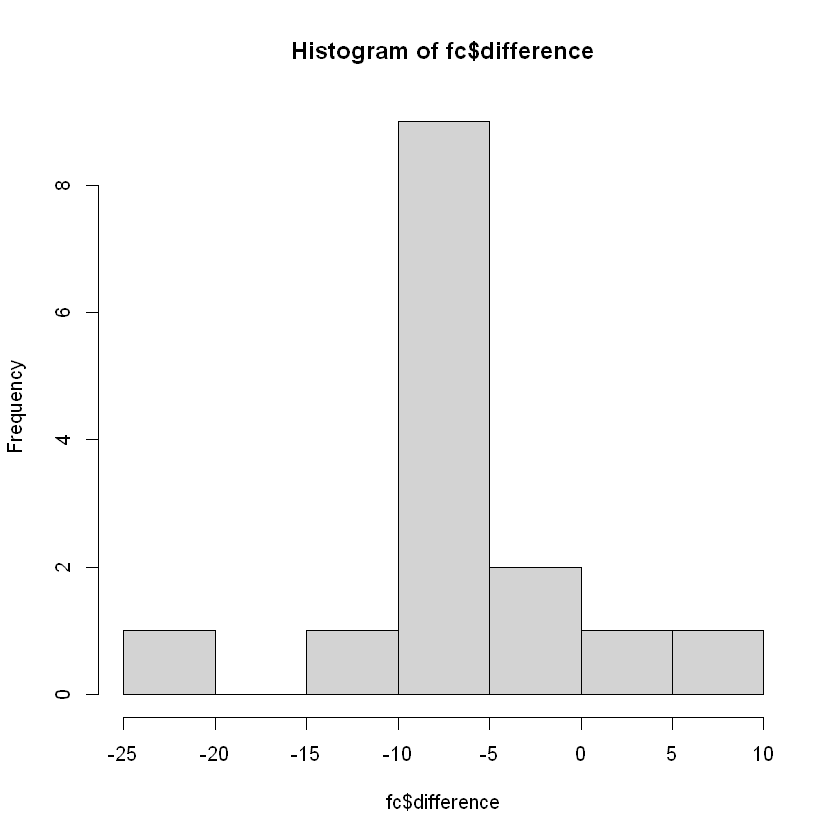

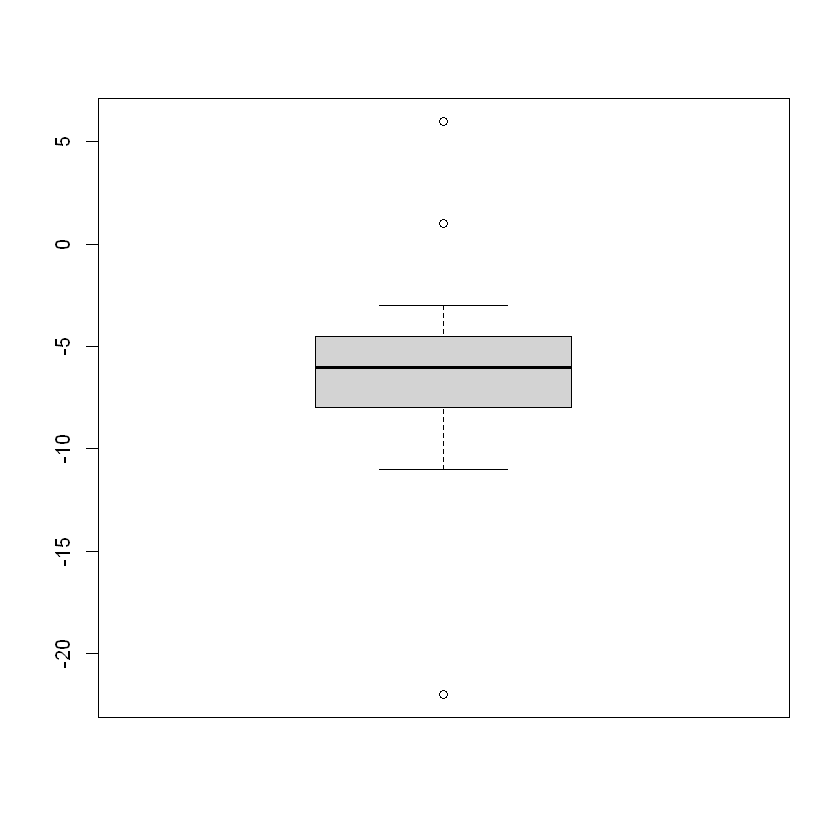

In [16]:
fc = read.table("data/data_exercice2.txt", header = TRUE)

# Description des données
# -> il s'agit d'un jeu de donnée apparié
head(fc)
summary(fc)

# On ajoute une colonne qui donne la différence de fréquence cardiaque
fc$difference = fc$avant - fc$apres
head(fc)

summary(fc$difference)
hist(fc$difference)
boxplot(fc$difference)
# On observe que la fréquence cardiaque semble être plus élevée après avoir entendu le bruit qu'avant


In [17]:
# Peut-on effectuer un test de Student pour échantillons appariés ?
nrow(fc)
shapiro.test(fc$difference)

# Non, la distribution des différences n'est pas normale, il faut utiliser un test de Wilcoxon pour échantillons appariés

# Hypothèses
# H0 : la médiane des différences vaut 0
# H1 : la médiane des différences est différent de 0

wilcox.test(fc$avant, fc$apres, paired = TRUE)

# Au seuil alpha = 5% (et alpha = 1%), on observe p < alpha, donc on rejette H0, ce qui signifie que le bruit a un effet sur la fréquence cardiaque
# et (cf. test en-dessous), le bruit augmente la fréquence cardiaques des sujets.
wilcox.test(fc$avant, fc$apres, paired = TRUE, alternative = "less")

[1] 15


	Shapiro-Wilk normality test

data:  fc$difference
W = 0.87219, p-value = 0.03634


Warning message in wilcox.test.default(fc$avant, fc$apres, paired = TRUE):
"impossible de calculer la p-value exacte avec des ex-aequos"



	Wilcoxon signed rank test with continuity correction

data:  fc$avant and fc$apres
V = 9.5, p-value = 0.00437
alternative hypothesis: true location shift is not equal to 0


Warning message in wilcox.test.default(fc$avant, fc$apres, paired = TRUE, alternative = "less"):
"impossible de calculer la p-value exacte avec des ex-aequos"



	Wilcoxon signed rank test with continuity correction

data:  fc$avant and fc$apres
V = 9.5, p-value = 0.002185
alternative hypothesis: true location shift is less than 0
